In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np

# Set the root directory and append it to sys.path safely
ROOT = r"C:\Users\barbe\Growing-virtual-materials-cellular-automata-meets-geostatistics"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pgsca.pgs_tools import make_gaussian_fields, make_lithotype_map
from pgsca.hybrid_tools import estimate_anisotropy, estimate_anisotropy_masked, recover_plurigaussian

# Verify everything is hooked up correctly
print("pgsca loaded successfully:", (Path(ROOT) / "pgsca" / "__init__.py").exists())

pgsca loaded successfully: True


In [2]:
def angle_err_deg(a_true, a_est):
    """Smallest angle between two orientations, in degrees (mod 180)."""
    d = abs(a_true - a_est) % np.pi
    return np.degrees(min(d, np.pi - d))

def make_known_map(grid_size, params_1, params_2, proportions, seed_1=0, seed_2=1):
    """
    3-phase lithotype map from KNOWN plurigaussian params.
    params_i = (alpha_rad, L_major, L_minor). 
    Returns (known_map, truth_dict).
    """
    a1, Lmaj1, Lmin1 = params_1
    a2, Lmaj2, Lmin2 = params_2
    
    f1, f2 = make_gaussian_fields(
        grid_size=grid_size,
        len_scale_1=[Lmaj1, Lmin1], angles_1=[a1, a1], seed_1=seed_1,
        len_scale_2=[Lmaj2, Lmin2], angles_2=[a2, a2], seed_2=seed_2,
    )
    
    p0, p1, p2 = proportions
    m = make_lithotype_map(f1, f2, Mat1=p0, Mat2=p1, Mat3=p2).astype(int)
    
    truth = dict(proportions=list(proportions), params_1=params_1, params_2=params_2)
    return m, truth

In [3]:
def evaluate_recovery(known_map, truth, **rec_kwargs):
    """Single-run: full recovery vs truth, printed side by side."""
    rec = recover_plurigaussian(known_map, **rec_kwargs)
    
    print(f"Proportions -> True: {np.round(truth['proportions'], 3)} | Recovered: {np.round(rec['proportions'], 3)}")
    
    for k in ('params_1', 'params_2'):
        at, Lmaj_t, Lmin_t = truth[k]
        ae, Lmaj_e, Lmin_e = rec[k]
        
        print(f"\n{k.upper()}:")
        print(f"  Alpha   | True: {np.degrees(at):6.1f}° | Recovered: {np.degrees(ae):6.1f}° | Err: {angle_err_deg(at, ae):5.1f}°")
        print(f"  L_major | True: {Lmaj_t:6.1f}  | Recovered: {Lmaj_e:6.1f}  | Err: {Lmaj_e - Lmaj_t:+6.1f}")
        print(f"  L_minor | True: {Lmin_t:6.1f}  | Recovered: {Lmin_e:6.1f}  | Err: {Lmin_e - Lmin_t:+6.1f}")
        
    return rec

def recovery_errors(truth_params, n_seeds=6, base_seed=0, **rec_kwargs):
    """
    Recovery over several realisations of the SAME params.
    Separates systematic bias (mean error) from estimator noise (std).
    """
    rows = {'params_1': [], 'params_2': []}
    
    for s in range(n_seeds):
        known_map, truth = make_known_map(
            seed_1=2*s + base_seed, seed_2=2*s + base_seed + 1, **truth_params
        )
        rec = recover_plurigaussian(known_map, **rec_kwargs)
        
        for k in ('params_1', 'params_2'):
            at, Lmaj_t, Lmin_t = truth[k]
            ae, Lmaj_e, Lmin_e = rec[k]
            rows[k].append((angle_err_deg(at, ae), Lmaj_e - Lmaj_t, Lmin_e - Lmin_t))
            
        print(f"✅ Seed set {s+1}/{n_seeds} done")

    for k in ('params_1', 'params_2'):
        arr = np.array(rows[k])  # cols: angle_err, dL_major, dL_minor
        print(f"\n--- {k.upper()} STATISTICS (n={len(arr)}) ---")
        print(f"  Angle Err   | Mean: {arr[:,0].mean():5.1f}° | Std: {arr[:,0].std():4.1f}°")
        print(f"  L_major Err | Mean: {arr[:,1].mean():+5.1f}  | Std: {arr[:,1].std():4.1f}")
        print(f"  L_minor Err | Mean: {arr[:,2].mean():+5.1f}  | Std: {arr[:,2].std():4.1f}")
        
    return rows

In [4]:
def field1_errors(alpha_deg, L_major, L_minor, p0=0.37, grid_size=256, n_seeds=6, **kw):
    """A/B tests just field 1 (estimate_anisotropy on the phase-0 indicator)."""
    a_true = np.radians(alpha_deg)
    errs = []
    
    for s in range(n_seeds):
        f1, f2 = make_gaussian_fields(
            grid_size=grid_size,
            len_scale_1=[L_major, L_minor], angles_1=[a_true, a_true], seed_1=s,
            len_scale_2=[20, 20], angles_2=[0, 0], seed_2=100 + s
        )
        m = make_lithotype_map(f1, f2, Mat1=p0, Mat2=(1-p0)/2, Mat3=(1-p0)/2).astype(int)
        B0 = (m == 0).astype(int)  # phase-0 = field 1 alone
        
        ae, Lmaj_e, Lmin_e = estimate_anisotropy(B0, **kw)[:3]
        errs.append((angle_err_deg(a_true, ae), Lmaj_e - L_major, Lmin_e - L_minor))
        print(f"Field 1 -> {s+1}/{n_seeds} done")
        
    arr = np.array(errs)
    print(f"\n--- FIELD 1 RESULTS ---")
    print(f"Angle | Mean: {arr[:,0].mean():5.1f}° | Std: {arr[:,0].std():4.1f}°")
    print(f"Lmaj  | Mean: {arr[:,1].mean():+5.1f}  | Std: {arr[:,1].std():4.1f}")
    print(f"Lmin  | Mean: {arr[:,2].mean():+5.1f}  | Std: {arr[:,2].std():4.1f}")
    return arr


def field2_errors(alpha2_deg, L_major, L_minor, proportions=(0.37, 0.25, 0.38), grid_size=256, n_seeds=6, **kw):
    """A/B tests just field 2 (estimate_anisotropy_masked). Field 1 fixed at 30 deg, L 25/12."""
    a2 = np.radians(alpha2_deg)
    p0, p1, p2 = proportions
    errs = []
    
    for s in range(n_seeds):
        f1, f2 = make_gaussian_fields(
            grid_size=grid_size,
            len_scale_1=[25, 12], angles_1=[np.radians(30), np.radians(30)], seed_1=s,
            len_scale_2=[L_major, L_minor], angles_2=[a2, a2], seed_2=100 + s
        )
        m = make_lithotype_map(f1, f2, Mat1=p0, Mat2=p1, Mat3=p2).astype(int)
        
        ae, Lmaj_e, Lmin_e = estimate_anisotropy_masked((m == 2).astype(int), m != 0, **kw)
        errs.append((angle_err_deg(a2, ae), Lmaj_e - L_major, Lmin_e - L_minor))
        print(f"Field 2 -> {s+1}/{n_seeds} done")
        
    arr = np.array(errs)
    print(f"\n--- FIELD 2 RESULTS ---")
    print(f"Angle | Mean: {arr[:,0].mean():5.1f}° | Std: {arr[:,0].std():4.1f}°")
    print(f"Lmaj  | Mean: {arr[:,1].mean():+5.1f}  | Std: {arr[:,1].std():4.1f}")
    print(f"Lmin  | Mean: {arr[:,2].mean():+5.1f}  | Std: {arr[:,2].std():4.1f}")
    return arr

In [5]:
# Define your test dictionaries
truth_params = dict(
    grid_size=256,
    params_1=(np.radians(30),  25.0, 12.0),
    params_2=(np.radians(110), 18.0, 15.0),
    proportions=(0.37, 0.25, 0.38),
)

truth_params_aniso = dict(
    grid_size=256,
    params_1=(np.radians(30),  25.0, 12.0),   # ratio ~2.1
    params_2=(np.radians(110), 24.0, 10.0),   # ratio ~2.4 (clearly anisotropic)
    proportions=(0.37, 0.25, 0.38),
)

print("🧪 STARTING TESTS...\n")

# 1. Run Field 1 Test
arr1_new = field1_errors(30, 25.0, 12.0, n_seeds=6)
print("-" * 40)

# 2. Run Field 2 Test
arr2_new = field2_errors(110, 24.0, 10.0, n_seeds=6)
print("-" * 40)

# 3. Run Full Pipeline Error Test
print("\n🧪 TESTING FULL PLURIGAUSSIAN PIPELINE...")
full_errors = recovery_errors(truth_params_aniso, n_seeds=6)

🧪 STARTING TESTS...

Field 1 -> 1/6 done
Field 1 -> 2/6 done
Field 1 -> 3/6 done
Field 1 -> 4/6 done
Field 1 -> 5/6 done
Field 1 -> 6/6 done

--- FIELD 1 RESULTS ---
Angle | Mean:   3.4° | Std:  1.5°
Lmaj  | Mean:  -0.3  | Std:  3.6
Lmin  | Mean:  +0.8  | Std:  2.0
----------------------------------------
Field 2 -> 1/6 done
Field 2 -> 2/6 done
Field 2 -> 3/6 done
Field 2 -> 4/6 done
Field 2 -> 5/6 done
Field 2 -> 6/6 done

--- FIELD 2 RESULTS ---
Angle | Mean:   4.3° | Std:  2.2°
Lmaj  | Mean:  -1.2  | Std:  2.9
Lmin  | Mean:  -0.3  | Std:  1.4
----------------------------------------

🧪 TESTING FULL PLURIGAUSSIAN PIPELINE...
✅ Seed set 1/6 done
✅ Seed set 2/6 done
✅ Seed set 3/6 done
✅ Seed set 4/6 done
✅ Seed set 5/6 done
✅ Seed set 6/6 done

--- PARAMS_1 STATISTICS (n=6) ---
  Angle Err   | Mean:   3.7° | Std:  1.6°
  L_major Err | Mean:  +0.7  | Std:  4.6
  L_minor Err | Mean:  +0.7  | Std:  1.9

--- PARAMS_2 STATISTICS (n=6) ---
  Angle Err   | Mean:   4.5° | Std:  1.9°
  L_major

## ca

In [9]:
from pgsca.karnaugh_tools import build_table, sequential_simulate, compute_morphology
import matplotlib.pyplot as plt

print("🧠 TRAINING KARNAUGH MAP TABLE...")

# 1. Generate the "Perfect" Target Map
target_map, truth = make_known_map(
    grid_size=128, 
    params_1=(np.radians(30),  25.0, 12.0),
    params_2=(np.radians(110), 24.0, 10.0),
    proportions=(0.37, 0.25, 0.38),
    seed_1=42, seed_2=43
)

# 2. Train the table on the target map predicting ITSELF. 
# This teaches it the "rules" of the geology (smoothness, edges, continuity)
table = build_table([(target_map, target_map)], neighbourhood='von_neumann')

n_trained_patterns = (table.sum(axis=1) > 0).sum()
print(f"✅ Table built successfully!")
print(f"   - Neighborhood Type: Von Neumann (4-way)")
print(f"   - Patterns seen in training: {n_trained_patterns} / 81")

🧠 TRAINING KARNAUGH MAP TABLE...
✅ Table built successfully!
   - Neighborhood Type: Von Neumann (4-way)
   - Patterns seen in training: 53 / 81


In [10]:
import copy

print("⚙️ RUNNING SEQUENTIAL SIMULATION...\n")

# 1. Create a "Rough Seed" by taking our perfect map and blasting 30% of it with noise
rough_seed = target_map.copy()
noise_mask = np.random.rand(128, 128) < 0.30  # Select 30% of pixels randomly
rough_seed[noise_mask] = np.random.choice([0, 1, 2], size=noise_mask.sum())

# 2. Run the simulation to see if the CA can clean up the noise!
final_grid, history, trace = sequential_simulate(
    table=table,
    shape=(128, 128),
    proportions=[0.37, 0.25, 0.38],
    n_passes=15,
    improvement_tol=0.001,
    initial_grid=rough_seed, # Start with the corrupted seed
    track_phase=2            
)

print("\n📊 --- SIMULATION HISTORY ---")
for i, delta in enumerate(history):
    print(f"  Pass {i+1:2d}: Change Fraction (δ) = {delta:.4f}")

⚙️ RUNNING SEQUENTIAL SIMULATION...

Converged after 8 pass(es)  (improvement = 0.0007 < 0.001)

📊 --- SIMULATION HISTORY ---
  Pass  1: Change Fraction (δ) = 0.2425
  Pass  2: Change Fraction (δ) = 0.0837
  Pass  3: Change Fraction (δ) = 0.0458
  Pass  4: Change Fraction (δ) = 0.0298
  Pass  5: Change Fraction (δ) = 0.0251
  Pass  6: Change Fraction (δ) = 0.0229
  Pass  7: Change Fraction (δ) = 0.0213
  Pass  8: Change Fraction (δ) = 0.0206


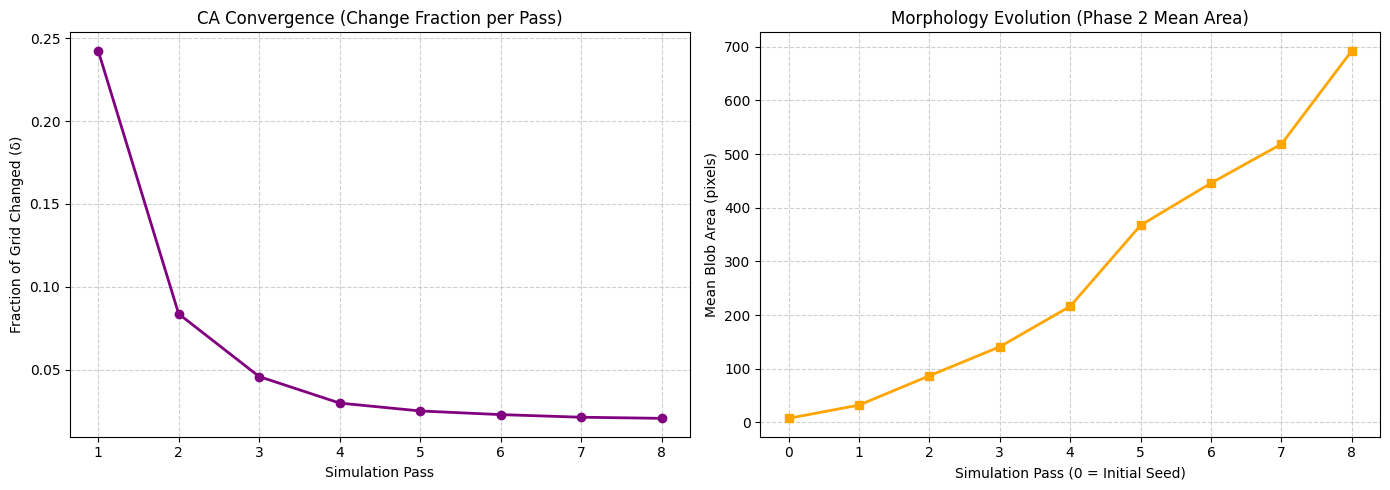

In [11]:
def plot_ca_diagnostics(history, trace):
    """Plots the convergence history and morphological evolution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Convergence Plot (Should drop down towards 0)
    axes[0].plot(range(1, len(history) + 1), history, marker='o', color='purple', linewidth=2)
    axes[0].set_title("CA Convergence (Change Fraction per Pass)")
    axes[0].set_xlabel("Simulation Pass")
    axes[0].set_ylabel("Fraction of Grid Changed (δ)")
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # 2. Morphology Evolution (Mean Area of Phase 2)
    mean_areas = [t['mean_area'] for t in trace]
    # trace includes the initial state (index 0), so it's len(history) + 1
    axes[1].plot(range(0, len(mean_areas)), mean_areas, marker='s', color='orange', linewidth=2)
    axes[1].set_title("Morphology Evolution (Phase 2 Mean Area)")
    axes[1].set_xlabel("Simulation Pass (0 = Initial Seed)")
    axes[1].set_ylabel("Mean Blob Area (pixels)")
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Render the plots
plot_ca_diagnostics(history, trace)

🎨 RENDERING RECONSTRUCTION RESULTS...
  Initial Corrupted Accuracy : 80.2%
  Final Reconstructed Accuracy: 94.4%



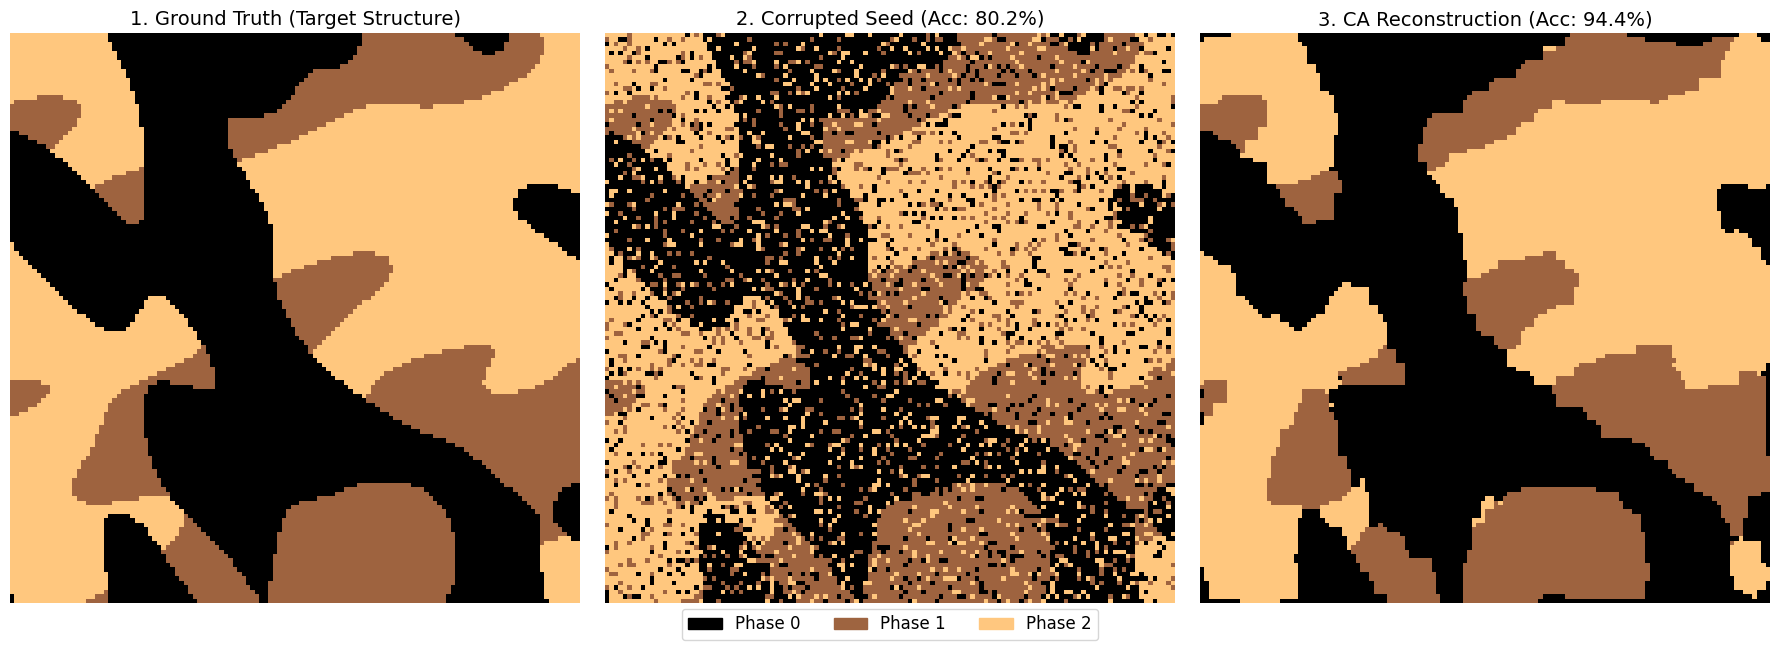

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("🎨 RENDERING RECONSTRUCTION RESULTS...")

# Calculate final pixel accuracy vs the perfect target
initial_accuracy = np.mean(rough_seed == target_map) * 100
final_accuracy = np.mean(final_grid == target_map) * 100

print(f"  Initial Corrupted Accuracy : {initial_accuracy:.1f}%")
print(f"  Final Reconstructed Accuracy: {final_accuracy:.1f}%\n")

# Setup the plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = 'copper'
labels = ['Phase 0', 'Phase 1', 'Phase 2']

# 1. Ground Truth (Target Map)
axes[0].imshow(target_map, cmap=cmap, vmin=0, vmax=2)
axes[0].set_title("1. Ground Truth (Target Structure)", fontsize=14)
axes[0].axis('off')

# 2. Corrupted Seed (Start State)
axes[1].imshow(rough_seed, cmap=cmap, vmin=0, vmax=2)
axes[1].set_title(f"2. Corrupted Seed (Acc: {initial_accuracy:.1f}%)", fontsize=14)
axes[1].axis('off')

# 3. Final CA Reconstruction
axes[2].imshow(final_grid, cmap=cmap, vmin=0, vmax=2)
axes[2].set_title(f"3. CA Reconstruction (Acc: {final_accuracy:.1f}%)", fontsize=14)
axes[2].axis('off')

# Add a shared legend
colormap = plt.colormaps[cmap]
patches = [
    Patch(color=colormap(0/2), label=labels[0]),
    Patch(color=colormap(1/2), label=labels[1]),
    Patch(color=colormap(2/2), label=labels[2])
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()